In [63]:
!pip install yfinance statsmodels

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [65]:
# Pharmaceutical company stock
stock = yf.download(
    'SUNPHARMA.NS',
    start='2020-01-01',
    end='2025-01-01'
)

/tmp/ipykernel_6857/1437186411.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(
[*********************100%***********************]  1 of 1 completed


In [66]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,SUNPHARMA.NS,SUNPHARMA.NS,SUNPHARMA.NS,SUNPHARMA.NS,SUNPHARMA.NS
Date,,,,,
2020-01-01,406.074036,408.084326,403.222272,404.811797,2321850
2020-01-02,406.681793,413.834600,403.923508,405.793524,4555670
2020-01-03,415.704651,421.127687,404.905289,406.401308,9457180
2020-01-06,411.356781,415.798069,406.821986,412.245021,4794923
2020-01-07,417.387604,418.883622,409.112776,412.712563,4504083


In [67]:
# External Variable 1:
# NIFTY Pharma Index
nifty = yf.download(
    '^CNXPHARMA',
    start='2020-01-01',
    end='2025-01-01'
)

/tmp/ipykernel_6857/3560518302.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download(
[*********************100%***********************]  1 of 1 completed


In [68]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^CNXPHARMA,^CNXPHARMA,^CNXPHARMA,^CNXPHARMA,^CNXPHARMA
Date,,,,,
2020-01-01,8047.100098,8076.649902,8018.950195,8060.299805,8898000
2020-01-02,8053.950195,8102.399902,8027.149902,8056.750000,12949000
2020-01-03,8111.950195,8189.799805,8026.299805,8053.000000,26218000
2020-01-06,7987.350098,8085.500000,7943.149902,8076.850098,17516000
2020-01-07,8036.500000,8087.649902,7973.950195,8014.100098,27940000


In [69]:
data = pd.DataFrame()

# Target variable
data['Close'] = stock['Close']

# Exogenous Variable 1
data['Volume'] = stock['Volume']

# Exogenous Variable 2
data['NiftyPharma'] = nifty['Close']

# Remove missing values
data.dropna(inplace=True)

In [70]:
data.head()

,Close,Volume,NiftyPharma
Date,,,
2020-01-01,406.074036,2321850,8047.100098
2020-01-02,406.681793,4555670,8053.950195
2020-01-03,415.704651,9457180,8111.950195
2020-01-06,411.356781,4794923,7987.350098
2020-01-07,417.387604,4504083,8036.500000


In [71]:
# Fix datetime index
data.index = pd.to_datetime(data.index)

# Business day frequency
data = data.asfreq('B')

# Remove missing values introduced by asfreq
data.dropna(inplace=True)

In [72]:
data.head()

,Close,Volume,NiftyPharma
Date,,,
2020-01-01,406.074036,2321850.0,8047.100098
2020-01-02,406.681793,4555670.0,8053.950195
2020-01-03,415.704651,9457180.0,8111.950195
2020-01-06,411.356781,4794923.0,7987.350098
2020-01-07,417.387604,4504083.0,8036.500000


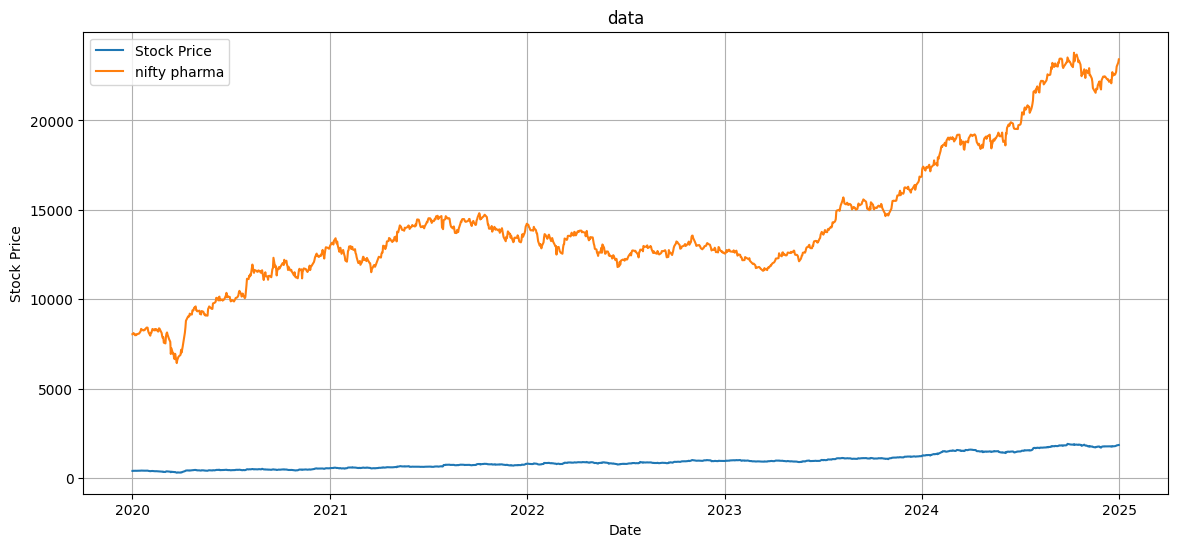

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    data.index,
    data['Close'],
    label='Stock Price'
)

plt.plot(
    data.index,
    data['NiftyPharma'],
    label='nifty pharma'
)

plt.title('data')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [56]:
y = data['Close']

exog = data[['Volume', 'NiftyPharma']]
exog.head()

,Volume,NiftyPharma
Date,,
2020-01-01,2321850.0,8047.100098
2020-01-02,4555670.0,8053.950195
2020-01-03,9457180.0,8111.950195
2020-01-06,4794923.0,7987.350098
2020-01-07,4504083.0,8036.500000


In [43]:
train_size = int(len(data) * 0.8)

train_y = y[:train_size]
test_y = y[train_size:]

train_exog = exog[:train_size]
test_exog = exog[train_size:]

In [74]:
model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(2,1,2)
)

# Train model
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  989
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -3335.510
Date:                Wed, 27 May 2026   AIC                           6685.019
Time:                        19:24:15   BIC                           6719.289
Sample:                             0   HQIC                          6698.052
                                - 989                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Volume       1.976e-07   3.12e-08      6.329      0.000    1.36e-07    2.59e-07
NiftyPharma     0.0542      0.001     42.647      0.000       0.052       0.057
ar.L1          -0.5198      0.063     -8.317    

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [50]:
forecast = model_fit.forecast(
    steps=len(test_y),
    exog=test_exog
)

# Assign the index of test_y to the forecast to align them correctly
forecast.index = test_y.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [51]:
mae = mean_absolute_error(test_y, forecast)

rmse = np.sqrt(
    mean_squared_error(test_y, forecast)
)

print("\n==============================")
print("Model Performance")
print("==============================")

print("MAE :", mae)
print("RMSE:", rmse)


Model Performance
MAE : 179.59019909545057
RMSE: 195.36959308135133


In [52]:
comparison = pd.DataFrame({
    'Actual': test_y,
    'Predicted': forecast
})

print("\n==============================")
print("Actual vs Predicted")
print("==============================")

print(comparison.head())


Actual vs Predicted
                 Actual    Predicted
Date                                
2023-12-28  1231.455078  1232.988691
2023-12-29  1228.820557  1231.457695
2024-01-01  1229.601196  1232.657023
2024-01-02  1264.676880  1255.703955
2024-01-03  1267.018555  1261.123714


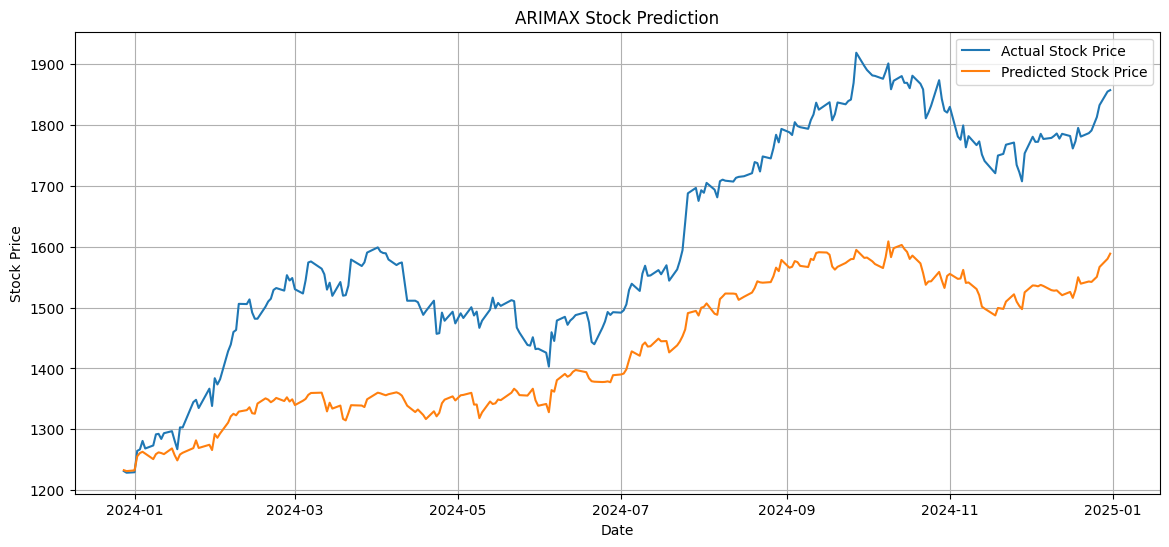

In [53]:
plt.figure(figsize=(14,6))

plt.plot(
    test_y.index,
    test_y,
    label='Actual Stock Price'
)

plt.plot(
    test_y.index,
    forecast,
    label='Predicted Stock Price'
)

plt.title('ARIMAX Stock Prediction')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [55]:
future_exog = [[
    stock['Volume'].mean(),
    nifty['Close'].mean()
]]

future_prediction = model_fit.forecast(
    steps=1,
    exog=future_exog
)
print(
    "Next Predicted Stock Value:",
    future_prediction.iloc[0]
)

Next Predicted Stock Value: 1089.268617925517


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [46]:
mae = mean_absolute_error(test_y, forecast)

rmse = np.sqrt(
    mean_squared_error(test_y, forecast)
)

print("\n==============================")
print("Model Performance")
print("==============================")

print("MAE :", mae)
print("RMSE:", rmse)


Model Performance
MAE : 179.59019909545057
RMSE: 195.36959308135133


In [47]:
comparison = pd.DataFrame({
    'Actual': test_y,
    'Predicted': forecast
})

print("\n==============================")
print("Actual vs Predicted")
print("==============================")

print(comparison.head())


Actual vs Predicted
                          Actual  Predicted
2023-12-28 00:00:00  1231.455078        NaN
2023-12-29 00:00:00  1228.820557        NaN
2024-01-01 00:00:00  1229.601196        NaN
2024-01-02 00:00:00  1264.676880        NaN
2024-01-03 00:00:00  1267.018555        NaN
